In [62]:
import pandas as pd
import seaborn as sns
import re

In [64]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [66]:
File = pd.read_csv('/content/drive/MyDrive/Analisis_Datos/train.csv', encoding='UTF8')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


<Axes: >

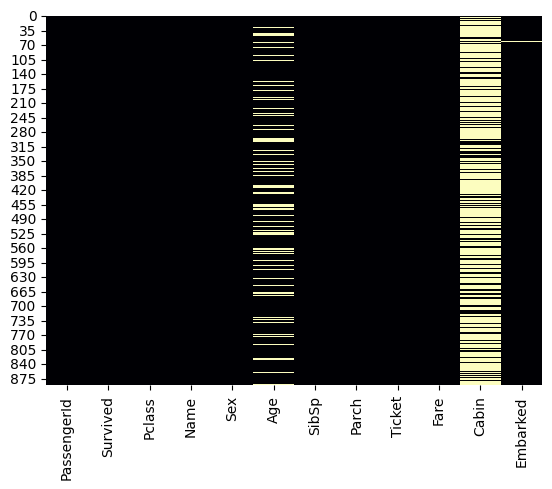

In [67]:
File.info()
sns.heatmap(File.isnull(), cbar=False, cmap="magma")

Fill each empty row of column embarked with "s"

In [68]:
Missing_data = File[File.Embarked.isnull()]
File["Embarked"].fillna("S", inplace=True)

Drop Cabin column, it contains too much missing data

In [69]:
File.drop(columns = ["Cabin"], inplace =True )

<Axes: >

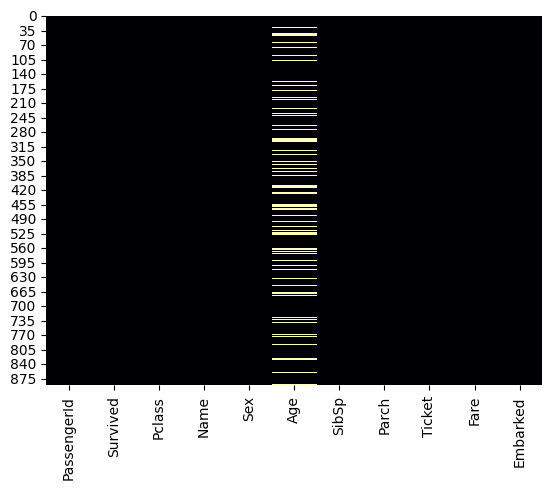

In [70]:
File.head(10)
sns.heatmap(File.isnull(), cbar=False, cmap="magma")

In the CSV there are titles like Rev, Mme, Mlle, Col.

In [106]:
#replace dictionary
replace = {
    "Rev" : "Mr",
    "Mme" : "Mrs",
    "Mlle" : "Miss",
    "Dr" : "Mr",
    "Col" : "Mr",
    "Capt" : "Mr",
    "Major" : "Mr"
}


File["Name"] = File["Name"].replace(replace, regex=True)


There are empty values in age, so we need fill it:
  

In [108]:
AgeMr = 0
AgeMiss = 0
AgeMrs = 0
AgeMaster = 0
countAgeMr = 0
countAgeMiss = 0
countAgeMrs = 0
countAgeMaster = 0
Age = 0
for i in range(len(File)):
  name = File.loc[i, "Name"]
  print(name)
  if "Mr" in name:
    if pd.notna(File.loc[i, "Age"]):
      Age = int(File.loc[i, "Age"])
      countAgeMr +=1
      AgeMr += Age
  if "Mrs" in name:
    if pd.notna(File.loc[i, "Age"]):
      Age = int(File.loc[i, "Age"])
      countAgeMrs +=1
      AgeMrs += Age
  if "Miss" in name:
    if pd.notna(File.loc[i, "Age"]):
      Age = int(File.loc[i, "Age"])
      countAgeMiss +=1
      AgeMiss += Age
  if "Master" in name:
    if pd.notna(File.loc[i, "Age"]):
      Age = int(File.loc[i, "Age"])
      countAgeMaster +=1
      AgeMaster += Age

print(countAgeMiss)
print(countAgeMaster)
print(countAgeMrs)
print(countAgeMr)



Braund, Mr. Owen Harris
Cumings, Mrs. John Bradley (Florence Briggs Thayer)
Heikkinen, Miss. Laina
Futrelle, Mrs. Jacques Heath (Lily May Peel)
Allen, Mr. William Henry
Moran, Mr. James
McCarthy, Mr. Timothy J
Palsson, Master. Gosta Leonard
Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
Nasser, Mrs. Nicholas (Adele Achem)
Sandstrom, Miss. Marguerite Rut
Bonnell, Miss. Elizabeth
Saundercock, Mr. William Henry
Andersson, Mr. Anders Johan
Vestrom, Miss. Hulda Amanda Adolfina
Hewlett, Mrs. (Mary D Kingcome) 
Rice, Master. Eugene
Williams, Mr. Charles Eugene
Vander Planke, Mrs. Julius (Emelia Maria Vandemoortele)
Masselmani, Mrs. Fatima
Fynney, Mr. Joseph J
Beesley, Mr. Lawrence
McGowan, Miss. Anna "Annie"
Sloper, Mr. William Thompson
Palsson, Miss. Torborg Danira
Asplund, Mrs. Carl Oscar (Selma Augusta Emilia Johansson)
Emir, Mr. Farred Chehab
Fortune, Mr. Charles Alexander
O'Dwyer, Miss. Ellen "Nellie"
Todoroff, Mr. Lalio
Uruchurtu, Don. Manuel E
Spencer, Mrs. William Augustus (Marie E

In [109]:
AverageAgeMiss = AgeMiss/countAgeMiss
AverageAgeMrs = AgeMrs/countAgeMrs
AverageAgeMaster = AgeMaster/countAgeMaster
AverageAgeMr = AgeMr/countAgeMr

In [110]:
for i in range(len(File)):
  name = File.loc[i, "Name"]
  if "Mr" in name:
    if pd.isna(File.loc[i, "Age"]):
      File.loc[i, "Age"] = AverageAgeMr
  if "Mrs" in name:
    if pd.isna(File.loc[i, "Age"]):
      File.loc[i, "Age"] = AverageAgeMrs
  if "Miss" in name:
    if pd.isna(File.loc[i, "Age"]):
      File.loc[i, "Age"] = AverageAgeMiss
  if "Master" in name:
    if pd.isna(File.loc[i, "Age"]):
      File.loc[i, "Age"] = AverageAgeMaster
  print(name)


Braund, Mr. Owen Harris
Cumings, Mrs. John Bradley (Florence Briggs Thayer)
Heikkinen, Miss. Laina
Futrelle, Mrs. Jacques Heath (Lily May Peel)
Allen, Mr. William Henry
Moran, Mr. James
McCarthy, Mr. Timothy J
Palsson, Master. Gosta Leonard
Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
Nasser, Mrs. Nicholas (Adele Achem)
Sandstrom, Miss. Marguerite Rut
Bonnell, Miss. Elizabeth
Saundercock, Mr. William Henry
Andersson, Mr. Anders Johan
Vestrom, Miss. Hulda Amanda Adolfina
Hewlett, Mrs. (Mary D Kingcome) 
Rice, Master. Eugene
Williams, Mr. Charles Eugene
Vander Planke, Mrs. Julius (Emelia Maria Vandemoortele)
Masselmani, Mrs. Fatima
Fynney, Mr. Joseph J
Beesley, Mr. Lawrence
McGowan, Miss. Anna "Annie"
Sloper, Mr. William Thompson
Palsson, Miss. Torborg Danira
Asplund, Mrs. Carl Oscar (Selma Augusta Emilia Johansson)
Emir, Mr. Farred Chehab
Fortune, Mr. Charles Alexander
O'Dwyer, Miss. Ellen "Nellie"
Todoroff, Mr. Lalio
Uruchurtu, Don. Manuel E
Spencer, Mrs. William Augustus (Marie E

<Axes: >

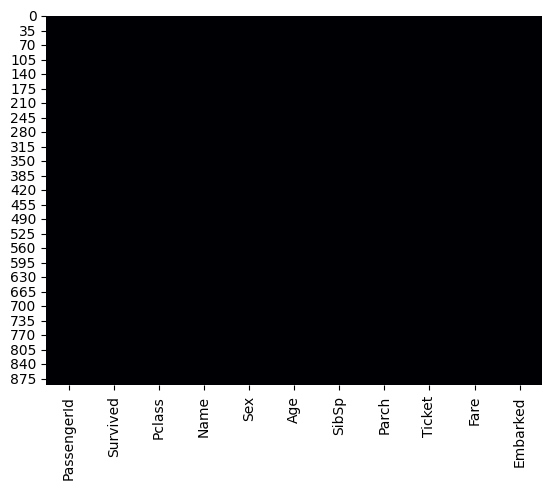

In [97]:

sns.heatmap(File.isnull(), cbar=False, cmap="magma")


In [111]:
File.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [114]:
File.to_csv("Titanic_limpio", sep=',', index=True, encoding='utf-8')
File.to_excel("Titanic_limpio.xlsx", index=False)